# Machine Learning Laboratory [AI29201]

# End Semester Lab Examination

<font color='gold'>Import Libraries </font>



In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report

### <font color='gold'> Task - 1 [Marks 1] </font>:
Load the human activity recognition dataset from the provided ZIP file.

In [98]:
X_train = pd.read_csv("/home/user/Downloads/UCI HAR Dataset/train/X_train.txt",delim_whitespace = True,header = None)
y_train = pd.read_csv("/home/user/Downloads/UCI HAR Dataset/train/y_train.txt",delim_whitespace = True,header = None)
X_test = pd.read_csv("/home/user/Downloads/UCI HAR Dataset/test/X_test.txt",delim_whitespace = True,header = None)
y_test = pd.read_csv("/home/user/Downloads/UCI HAR Dataset/test/y_test.txt",delim_whitespace = True,header = None)

### <font color='gold'> Task - 2 [Marks 1] </font>:
Check the dataset for missing feature values and duplicate entries.

Standardize the training and test sets.

In [99]:
print("Missing values per column:")
data = pd.concat([X_train,y_train],axis = 1)
print(data.isnull().sum())
print("Duplicate rows:", data.duplicated().sum())


Missing values per column:
0      0
1      0
2      0
3      0
4      0
      ..
557    0
558    0
559    0
560    0
0      0
Length: 562, dtype: int64
Duplicate rows: 0


In [100]:
preprocessor = StandardScaler()
X_scaled = preprocessor.fit_transform(X_train)
X_test_scaled  = preprocessor.transform(X_test)
print("Feature scaling done. Example scaled values:")
print(X_scaled[:5])

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

Feature scaling done. Example scaled values:
[[ 0.20064157 -0.0636826  -0.41962845 ... -0.68721921  0.40794614
  -0.00756789]
 [ 0.05594788  0.03148567 -0.25390836 ... -0.694138    0.40911698
   0.00787517]
 [ 0.07351535 -0.04341648 -0.07629468 ... -0.702239    0.4102883
   0.02650234]
 [ 0.06669577 -0.20842166 -0.24971245 ... -0.70168389  0.41465007
   0.03171414]
 [ 0.03046897  0.02758722 -0.10984784 ... -0.70015171  0.42546296
   0.04522502]]


### <font color='gold'> Task - 3 [Marks 2] </font>:
Perform activity classification on the dataset using SVM from scikit-learn. Use RBF kernel and default parameters.  

In [119]:
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_scaled, y_train)

SVC(random_state=42)

### <font color='gold'> Task - 4 [Marks 1] </font>:

Show the classification report of the SVM classifier on this dataset and report the overall accuracy. You can use sklearn functions for accuracy score and classification report.

In [86]:
y_pred_rbf = svm_rbf.predict(X_test_scaled)
print("RBF Kernel SVM Classification Report:\n", classification_report(y_test, y_pred_rbf))

RBF Kernel SVM Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.97      0.97       496
           2       0.93      0.97      0.95       471
           3       0.98      0.92      0.95       420
           4       0.94      0.90      0.92       491
           5       0.92      0.95      0.93       532
           6       1.00      1.00      1.00       537

    accuracy                           0.95      2947
   macro avg       0.95      0.95      0.95      2947
weighted avg       0.95      0.95      0.95      2947



### <font color='gold'> Task - 5 [Marks 4] </font>:
Implement LDA from scratch to project a data point to a new features space having D dimensions, where d varies from

1 to minimum(n, C-1), where n is the number of features in the original feature space, and C is the number of classes.  



In [134]:
from sklearn.preprocessing import StandardScaler

class LDAFromScratch:
    def __init__(self, n_components):
        self.n_components = n_components
        self.scalings_ = None

    def fit(self, X, y):
        # Compute overall mean
        mean_overall = np.mean(X, axis=0)
        classes = np.unique(y)
        S_w = np.zeros((X.shape[1], X.shape[1]))  # Within-class scatter matrix
        S_b = np.zeros((X.shape[1], X.shape[1]))  # between-class scatter matrix

        for c in classes:
            X_c = X[y == c]
            mean_c = np.mean(X_c, axis=0)

            # Within-class scatter
            S_w += (X_c - mean_c).T.dot(X_c - mean_c)

            #S_w += np.cov(X_c - mean_c, rowvar=False) * (X_c.shape[0] - 1)
            # Between-class scatter
            n_c = X_c.shape[0]
            mean_diff = (mean_c - mean_overall).reshape(X.shape[1], 1)
            S_b += n_c * (mean_diff).dot(mean_diff.T)
        delt = 1e-6*(np.eye(S_w.shape[0],S_w.shape[0]))
        S_w += delt
        # Eigen decomposition of the matrix S_W^-1 * S_B
        eigvals, eigvecs = np.linalg.eig(np.linalg.inv(S_w).dot(S_b))

        # Sort the eigenvalues and eigenvectors
        sorted_indices = np.argsort(eigvals)[::-1]
        eigvecs_sorted = eigvecs[:, sorted_indices]

        # Select the top n_components
        self.scaling = eigvecs_sorted[:, :self.n_components]
        return self.scaling


    def transform(self, X):
        return X.dot(self.scaling)


### <font color='gold'> Task - 6 [Marks 2] </font>:
Project the data to the new d-dimensional feature space using the projection matrix found by your LDA implementation.  

In [102]:
c = 6

In [135]:
lda_scratch = LDAFromScratch(n_components=min(3,c-1))
lda_scratch.fit(X_scaled, pd.DataFrame(y_train).values.reshape(-1))
X_lda_scratch = lda_scratch.transform(X_scaled) 

### <font color='gold'> Task - 7 [Marks 2] </font>:
Train the same SVM classifier from step 3 (RBF kernel and default parameters) to perform classification using the newly projected d-dimensional data points.    

In [136]:
from sklearn.metrics import accuracy_score
accuracy = [0]
def svm_train_rbf(d):
    lda_scratch = LDAFromScratch(n_components=d)
    lda_scratch.fit(X_scaled, pd.DataFrame(y_train).values.reshape(-1))
    X_lda_scratch = lda_scratch.transform(X_scaled).real
    svm_rbf = SVC(kernel='rbf', random_state=42)
    svm_rbf.fit(X_lda_scratch, y_train)
    X_lda_scratch_test = lda_scratch.transform(X_test_scaled).real
    y_pred_rbf = svm_rbf.predict(X_lda_scratch_test)
    accuracy.append(accuracy_score(y_test,y_pred_rbf))
for d in range(1,c):
    svm_train_rbf(d)
print(accuracy)


[0, 0.5887343060739735, 0.6430268069222939, 0.8018323719036308, 0.8791991856124872, 0.9626739056667798]


### <font color='gold'> Task - 8 [Marks 1] </font>:
Plot the overall classification accuracy as a function of d.  

/home/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

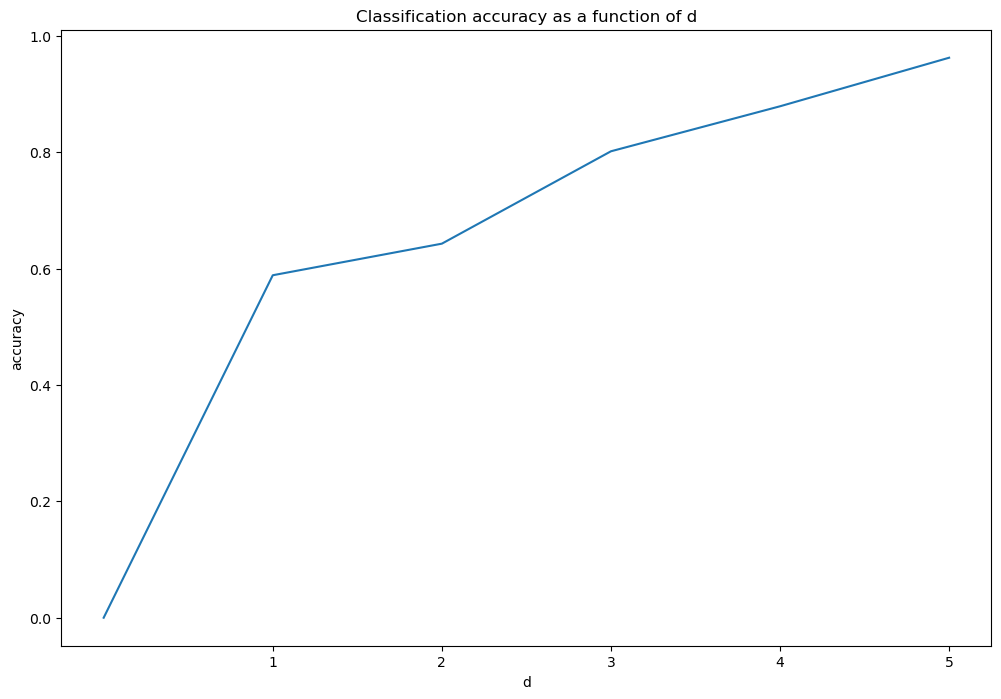

In [137]:
plt.figure(figsize=(12,8))
sns.lineplot(accuracy)
plt.title("Classification accuracy as a function of d")
plt.xlabel("d")
plt.ylabel("accuracy")
plt.xticks([1,2,3,4,5])
plt.show()

### <font color='gold'> Task - 9 [Marks 2] </font>:
What is the value of d for which you obtained the best classification accuracy? How does this accuracy compare to the accuracy obtained on the original feature space?  - 1 mark


Show the classification report corresponding to the best value of d. - 1 mark

From the graph, the accuracy is best for d=5
Accuracy obtained on original feature space: 0.95
Accuracy obtained on 5 dimensional feature space: 0.96

In [138]:
lda_scratch = LDAFromScratch(n_components=5)
lda_scratch.fit(X_scaled, pd.DataFrame(y_train).values.reshape(-1))
X_lda_scratch = lda_scratch.transform(X_scaled).real
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_lda_scratch, y_train)
X_lda_scratch_test = lda_scratch.transform(X_test_scaled).real
y_pred_rbf = svm_rbf.predict(X_lda_scratch_test)
accuracy.append(accuracy_score(y_test,y_pred_rbf))
print("SVM Classification Report for d=5:\n", classification_report(y_test, y_pred_rbf))

SVM Classification Report for d=5:
               precision    recall  f1-score   support

           1       0.98      0.99      0.98       496
           2       0.97      0.98      0.97       471
           3       1.00      0.98      0.99       420
           4       0.95      0.88      0.91       491
           5       0.89      0.96      0.93       532
           6       1.00      1.00      1.00       537

    accuracy                           0.96      2947
   macro avg       0.96      0.96      0.96      2947
weighted avg       0.96      0.96      0.96      2947



### <font color='gold'> Task - 10 [Marks 3] </font>:
Use sklearn’s implementation of LDA for the best values of d to project the data to the d-dimensional feature space, train the SVM classifier on this projected feature space and show the classification report and accuracy - 2 marks

How do the performance metrics compare with your from scratch implementation of LDA? - 1 mark

In [139]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize and fit LDA using scikit-learn
lda_sklearn = LinearDiscriminantAnalysis(n_components=5)
X_lda_sklearn = lda_sklearn.fit_transform(X_scaled,y_train)
x_lda_sklearn_test = lda_sklearn.transform(X_test_scaled)
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_lda_sklearn, y_train)
y_pred = svm_rbf.predict(x_lda_sklearn_test)

In [140]:
print("class. report",classification_report(y_test,y_pred))

class. report               precision    recall  f1-score   support

           1       0.98      0.99      0.98       496
           2       0.97      0.98      0.97       471
           3       1.00      0.98      0.99       420
           4       0.95      0.88      0.92       491
           5       0.90      0.96      0.93       532
           6       1.00      1.00      1.00       537

    accuracy                           0.97      2947
   macro avg       0.97      0.96      0.97      2947
weighted avg       0.97      0.97      0.96      2947



### <font color='gold'> Task - 11 [Marks 1] </font>:
For the value of d that gives the best classification accuracy, report the compression ratio achieved by LDA.  

In [141]:
5/X_train.shape[1]

0.008912655971479501